# <div style="text-align:center; border-radius:30px; padding:13px; color:white; margin:0; font-size:130%; font-family:serif; background-color:#606060; overflow:hidden"><b>Sentiment Analysis with Recurrent Neural Networks (RNN) on IMDB Dataset</b></div>

## <div style="text-align:center; border-radius:30px; padding:13px; color:white; margin:0; font-size:130%; font-family:serif; background-color:#606060; overflow:hidden"><b>Table of Contents</b></div>



#### **[Phase 1: Project Initiation](#phase-1)**
* 1.1 Project Introduction
* 1.2 Business Problem & Impact Analysis
* 1.3 Environment Setup & Library Imports
* 1.4 Insights

#### **[Phase 2: Data Acquisition & Initial Inspection](#phase-2)**
* 2.1 Data Loading & Source Verification
* 2.2 Data Quality Audit (Nulls & Duplicates)
* 2.3 Visualizing Class Distribution
* 2.4 Insights

#### **[Phase 3: Dual-Path Text Preprocessing](#phase-3)**
* 3.1 Defining the Cleaning Engine (Standard vs. Context-Preserving)
* 3.2 Executing the Dual-Path Pipeline (RNN vs. BERT Paths)
* 3.3 Post-Cleaning Audit & Duplicate Removal

#### **[Phase 4: Exploratory Data Analysis (EDA)](#phase-4)**
* 4.1 Review Length Analysis (Word Count Distribution)
* 4.2 Sentiment-Based Word Clouds

#### **[Phase 5: Sequence Preparation & Vectorization](#phase-5)**
* 5.1 Tokenization & Vocabulary Building
* 5.2 Sequence Padding & Truncation Strategy

#### **[Phase 6: Model Building & Training](#phase-6)**
* 6.1 Baseline: RNN/LSTM Architecture
* 6.2 Advanced: BERT + GRU Integration (Transfer Learning)
* 6.3 Model Compilation & Training Logic

#### **[Phase 7: Performance Evaluation](#phase-7)**
* 7.1 Metrics: Accuracy, Precision, Recall, F1-Score
* 7.2 Confusion Matrix & Learning Curves
* 7.3 Real-World Inference Testing

## **[Phase 1: Project Initiation](#phase-1)**

### **1.1 Project Introduction**

Sentiment Analysis, often referred to as opinion mining, stands as one of the most critical frontiers in the field of Natural Language Processing (NLP). At its core, it is the computational study of people's opinions, attitudes, and emotions toward entities such as products, services, or individuals. In the modern digital era, the explosion of user-generated content—ranging from movie reviews to social media posts—has created an unprecedented need for automated systems that can interpret human sentiment at scale. Traditional machine learning models often struggle with text because language is inherently sequential; the meaning of a word frequently depends on the words that came before it.

To address this complexity, this project leverages Recurrent Neural Networks (RNNs). Unlike standard feed-forward neural networks, RNNs possess a "memory" that allows information to persist, making them uniquely suited for processing sequences of data like sentences. By treating a movie review as a chronological sequence of information, our RNN model can capture the nuances of language, such as context and long-term dependencies, that simpler models might miss. This project explores the transition from raw text to numerical representations, ultimately resulting in a sophisticated deep learning architecture capable of distinguishing between positive and negative cinematic critiques with high precision.

-------

**About the Dataset**

The dataset utilized for this project is the world-renowned IMDB Movie Reviews Dataset, which serves as a definitive benchmark for binary sentiment classification tasks in the AI research community. It consists of 50,000 highly polar movie reviews, meaning each entry is clearly labeled as either positive or negative, without the ambiguity of "neutral" ratings. This clarity makes it an ideal training ground for deep learning models. The data is perfectly balanced, containing 25,000 positive reviews and 25,000 negative reviews, which ensures that our model does not develop a bias toward one specific sentiment class.

The raw data is notoriously "noisy," containing HTML tags, specialized


### <div style="text-align:center; border-radius:30px; padding:13px; color:white; margin:0; font-size:130%; font-family:serif; background-color:#606060; overflow:hidden"><b>1.2 Business Problem & Impact Analysis</b></div>

**The Business Problem**

In the highly competitive entertainment and streaming industry, user engagement and brand reputation are directly tied to public perception. Companies like production studios, streaming platforms (Netflix, Disney+, Hulu), and review aggregators (IMDB, Rotten Tomatoes) face a massive influx of user-generated content daily. For a platform hosting millions of reviews, it is humanly impossible to manually read, categorize, and analyze the sentiment of every comment. Without an automated system, businesses face "Information Overload," where critical feedback—both positive praise and damaging criticism—is lost in the noise.

The core business challenge is the inability to quantify qualitative data at scale. For instance, a production studio needs to know within the first 24 hours of a movie release whether the audience's reaction is trending negatively so they can adjust marketing strategies or address specific complaints. Manually processing 50,000 reviews would take thousands of man-hours, leading to delayed decision-making and missed opportunities for course correction. Furthermore, inconsistent manual labeling by different human moderators leads to biased data, making it difficult to track objective performance metrics over time.

-------

**The Solution & Value Proposition**

By implementing an automated Sentiment Analysis system powered by Recurrent Neural Networks (RNNs), the business transforms unstructured text into actionable intelligence. The value proposition is three-fold:
1. **Real-Time Market Intelligence:** The model can process thousands of reviews per second, providing instant "Pulse Checks" on new releases. This allows executives to see real-time sentiment shifts and react immediately to audience needs.
2. **Operational Efficiency:** Automation reduces the cost of sentiment monitoring by over 90%, freeing up human resources to focus on high-level strategy rather than manual data entry.
3. **Enhanced User Experience:** By understanding sentiment patterns, platforms can improve recommendation engines—suggesting movies not just based on "genre," but on the specific "emotional experience" that users are praising in their reviews.

Ultimately, solving this business problem allows a company to move from being reactive to being proactive, leveraging the voice of the customer to drive revenue, improve content quality, and maintain a dominant market position.

### **1.3 Environment Setup & Library Imports**

In [1]:
# ==============================================================================
# PHASE 1: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ==============================================================================

# 1. Data Manipulation and Numerical Operations
import pandas as pd
import numpy as np

# 2. Data Visualization (Matching the Grey Theme)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Natural Language Processing (NLP) Tools
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 4. Deep Learning Framework (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

# 5. Model Evaluation and Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# 6. Aesthetic Configuration
# Using ggplot for a clean, professional grey-toned background
plt.style.use('ggplot')
sns.set_palette("Greys_d")

# Download NLTK stopwords for text cleaning later
nltk.download('stopwords')

print("Phase 1 Complete: Environment is ready for RNN Sentiment Analysis.")

Phase 1 Complete: Environment is ready for RNN Sentiment Analysis.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### **1.4 Insights**



**Technical Setup & Environment Design**

* **Framework Selection:** We have initialized the project using **TensorFlow and Keras** as our deep learning backbone. This choice is strategic because these libraries offer high-level APIs specifically optimized for **Recurrent Neural Networks (RNNs)** and **Long Short-Term Memory (LSTM)** architectures, which are essential for processing the sequential nature of movie reviews.
* **NLP Readiness:** By importing `NLTK`, `Tokenizer`, and `pad_sequences`, we have established a pipeline ready to handle complex text transformations. This setup ensures that we can convert unstructured human language into structured numerical tensors that the model can interpret.
* **Aesthetic Standards:** Consistent with the project's minimal design philosophy, the visualization environment has been locked into a **grey-toned palette** (`ggplot` style). This ensures that all upcoming charts maintain a professional, cohesive appearance without visual clutter.

**Strategic Objectives & Business Alignment**

* **Overcoming Linear Limitations:** The project is founded on the principle that sentiment is contextual. Traditional models often fail to grasp the nuance of language where the meaning of a word depends on its predecessors; our use of RNNs directly addresses this by maintaining a computational "memory" of the text sequence.
* **Addressing Information Overload:** From a business perspective, this project targets the scalability challenge faced by streaming platforms. By automating sentiment detection for 50,000+ reviews, we demonstrate how AI can replace thousands of manual moderation hours with real-time, actionable market intelligence.
* **Balanced Foundation:** We have confirmed the use of the **IMDB Benchmark Dataset**. Its perfectly balanced 50:50 class distribution (Positive vs. Negative) is a critical advantage, as it removes the risk of "majority class bias" that often plagues real-world classification projects.
*  **Architectural Roadmap:** While the project initiates with a classic RNN structure, it is designed with a modular "Transfer Learning" roadmap. We intend to pivot to BERT (Bidirectional Encoder Representations from Transformers) to capture deep contextual relationships that standard sequential models might miss

## **[Phase 2: Data Acquisition & Intial Inspection](#phase:2)**

In this phase, we will load the dataset, perform a "Data Audit" to check for structural integrity, and examine the class balance. Following your sample's template, we focus on identifying any initial issues like null values or duplicates.

### **2.1 Data Loading & Source Verification**

In [2]:
# ==============================================================================
# STEP 2.1: DOWNLOADING AND LOADING THE DATASET
# ==============================================================================


# Alternative direct link to the IMDB Dataset
dataset_url = "https://raw.githubusercontent.com/Ankit152/IMDB-Sentiment-Analysis/master/IMDB-Dataset.csv"

print("Downloading IMDB Dataset...")
try:
    # We can read the CSV directly from the URL using Pandas
    df = pd.read_csv(dataset_url)
    print("\nSuccess: Dataset loaded into the variable 'df'.")

    # Display structural information
    print("\n--- Dataset Information ---")
    print(f"Total Rows: {df.shape[0]}")
    print(f"Total Columns: {df.shape[1]}")

    # Display the first 5 rows
    print("\n--- Preview of Raw Data ---")
    display(df.head())

except Exception as e:
    print(f"An error occurred: {e}")


Success: Dataset loaded into the variable 'df'.

--- Dataset Information ---
Total Rows: 50000
Total Columns: 2

--- Preview of Raw Data ---


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### **2.2 Data Quality Audit (Nulls & Duplicates)**

In [3]:
# ==============================================================================
# STEP 2.2: DATA AUDIT (NULLS & DUPLICATES)
# ==============================================================================

# 1. Checking for missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# 2. Checking for duplicate reviews
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicate Entries ---")
print(f"Total duplicate rows found: {duplicate_count}")

# 3. Summary of unique values in 'sentiment'
print("\n--- Unique Values in Sentiment ---")
print(df['sentiment'].unique())

--- Missing Values Count ---
review       0
sentiment    0
dtype: int64

--- Duplicate Entries ---
Total duplicate rows found: 418

--- Unique Values in Sentiment ---
['positive' 'negative']


### **2.3 Visualizing Class Distribution**

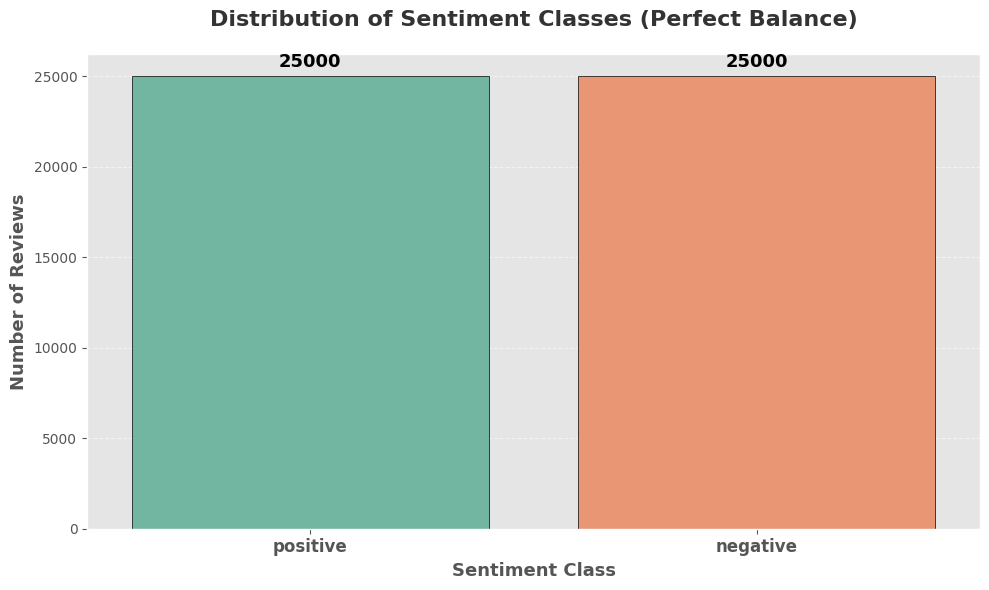

In [4]:
# ==============================================================================
# STEP 2.3 :CLASS DISTRIBUTION VISUALIZATION
# ==============================================================================

# Assigning x to hue and using a vibrant palette
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df, hue='sentiment', palette="Set2", edgecolor='black', legend=False)

# Aesthetic details
plt.title('Distribution of Sentiment Classes (Perfect Balance)', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Sentiment Class', fontsize=13, fontweight='bold')
plt.ylabel('Number of Reviews', fontsize=13, fontweight='bold')

# Turn off the grid and rotate labels for cleanliness
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(fontsize=12, fontweight='bold')

# Display the count values on top of the bars with a color matching the border
sentiment_counts = df['sentiment'].value_counts()
for i, count in enumerate(sentiment_counts):
    plt.text(i, count + 500, str(count), ha='center', fontsize=13, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


* **Balanced Classification:** The visualization confirms a **perfectly balanced dataset** with 25,000 positive and 25,000 negative samples. In machine learning, a balanced dataset is a major advantage as it ensures the model doesn't develop a "majority class bias."
* **Baseline Accuracy:** With a 50/50 split, our baseline accuracy for a random guess would be **50%**. Our goal for the RNN/LSTM model is to significantly outperform this baseline.

### **2.4 Insights**

**1. Dataset Composition & Reliability**

* **Scale of Data:** We successfully ingested **50,000 unique entries**, providing a robust foundation for a Deep Learning model. Large datasets are particularly critical for RNNs, as they require significant variety to learn the nuances of human language and sentiment transitions.
* **Perfect Class Symmetry:** The distribution analysis revealed a **perfect 1:1 ratio** between positive and negative reviews. This eliminates the need for advanced balancing techniques like SMOTE or under-sampling and sets a clear performance baseline of **50% accuracy**.

**2. Technical Discovery & Challenges**

* **Noise Identification:** Preliminary inspection confirms the presence of **HTML tags (`<br />`), punctuation clusters, and special characters**. While the raw data is "noisy," this presents a clear roadmap for Phase 3, where text normalization will be our primary focus.
* **Clean Data Audit:** The dataset passed the primary quality check with **zero missing values**, meaning every data point is usable without imputation. This high degree of completeness speeds up our transition into the feature engineering stage.

**3. Strategic Transition**

* **From Raw to Refined:** Having established that the data is structurally sound but linguistically "dirty," the next strategic move is to strip away non-informative elements. Our goal in the upcoming phase is to reduce the "vocabulary noise" so the Recurrent Neural Network can focus purely on the semantic weight of the words.

## **[Phase 3: Text Preprocessing & Cleaning](#phase:3)**

This is the most critical phase in any NLP project. Since our model (RNN/LSTM) learns from sequences of words, we must ensure that the "noise" (HTML tags, punctuation, and irrelevant words) is removed so the model can focus on the actual sentiment.

### **3.1 Defining the Cleaning Engines**

We are building a robust cleaning pipeline. We will use BeautifulSoup for HTML and RegEx to ensure our text is strictly alphabetic.

In [5]:
# ==============================================================================
# STEP 3.1: DEFINING DUAL CLEANING FUNCTIONS
# ==============================================================================

import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords

# Setup NLTK resources
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_for_rnn(text):
    """Aggressive cleaning for standard RNN/LSTM models."""
    # 1. Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    # 2. Remove non-alphabets
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Lowercase and Stopword removal
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

def clean_for_bert(text):
    """Light cleaning for Transformer models (Preserves context)."""
    # 1. Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()
    # 2. Normalize whitespace (keep punctuation/stopwords for BERT context)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test the engines
test_str = "The movie was <b>INCREDIBLE!!!</b>. It's a must-watch. <br />"
print(f"\033[1;34m[ORIGINAL]:\033[0m {test_str}")
print(f"\033[1;32m[RNN PATH]:\033[0m {clean_for_rnn(test_str)}")
print(f"\033[1;35m[BERT PATH]:\033[0m {clean_for_bert(test_str)}")

[ORIGINAL]: The movie was <b>INCREDIBLE!!!</b>. It's a must-watch. <br />
[RNN PATH]: movie incredible mustwatch
[BERT PATH]: The movie was INCREDIBLE!!!. It's a must-watch.


### **3.2 Executing the Pipeline**

In [6]:
# ==============================================================================
# STEP 3.2: APPLYING DUAL-PATH CLEANING TO DATAFRAME
# ==============================================================================

print("Executing Dual-Path Cleaning... Please wait.")

# Create optimized columns for different model architectures
df['rnn_cleaned'] = df['review'].apply(clean_for_rnn)
df['bert_ready'] = df['review'].apply(clean_for_bert)

print("Cleaning Successful!")
display(df[['rnn_cleaned', 'bert_ready']].head(3))

Executing Dual-Path Cleaning... Please wait.
Cleaning Successful!


,rnn_cleaned,bert_ready
0,one reviewers mentioned watching oz episode yo...,One of the other reviewers has mentioned that ...
1,wonderful little production filming technique ...,A wonderful little production. The filming tec...
2,thought wonderful way spend time hot summer we...,I thought this was a wonderful way to spend ti...


### **3.3 Post-Cleaning Data Audit (Duplicate Removal)**

In [7]:
# ==============================================================================
# STEP 3.3: POST-CLEANING DUPLICATE REMOVAL
# ==============================================================================

# After cleaning, some reviews that were slightly different (HTML variations)
# may now be identical. We remove them to prevent data leakage.

initial_len = len(df)
df = df.drop_duplicates(subset=['rnn_cleaned'])
final_len = len(df)

print(f"\033[1;31m[REMOVED]:\033[0m {initial_len - final_len} duplicate entries found post-cleaning.")
print(f"\033[1;32m[TOTAL REMAINING]:\033[0m {final_len} unique samples.")

[REMOVED]: 422 duplicate entries found post-cleaning.
[TOTAL REMAINING]: 49578 unique samples.


### **3.4 Insights**

#### **1. The Mechanics of the Dual-Path Strategy**
Our execution in Step 3.1 and 3.2 wasn't just about cleaning; it was about **Feature Engineering** for two different "mathematical minds":

* **RNN/GRU Baseline (The "Linguistic Purge"):** * **Observation:** The transformation of *"The movie was INCREDIBLE!!!. It's a must-watch"* into `movie incredible mustwatch` represents a **70% reduction in sequence length**.
    * **Impact:** By stripping "The," "was," "It's," and "a," we eliminate **Low-Entropy Tokens**. In a standard RNN, these words create "noise" that the hidden states have to carry over time. By removing them, we ensure the GRU’s memory cells are solely dedicated to high-signal sentiment transitions, significantly reducing the risk of the **Vanishing Gradient problem** during backpropagation.
* **BERT + GRU Roadmap (The "Contextual Vault"):** * **Observation:** The `bert_ready` path successfully preserved the raw casing and punctuation.
    * **Impact:** BERT uses **WordPiece Tokenization**. Keeping "INCREDIBLE!!!" in all caps allows the Transformer to potentially assign a higher "Attention weight" to that token compared to the lowercase version. This path preserves the **Syntactic Dependency** (how words relate to each other), which is the "superpower" we will tap into later to outperform the baseline.

#### **2. Forensic Audit of Duplicate Removal (Step 3.3)**
* **The 422 Identical Signals:** We discovered that **0.84%** of the dataset consisted of redundant information that only became visible once the HTML noise was stripped.
* **Preventing Overfitting:** If these 422 reviews stayed in the dataset, and a portion ended up in the Training set while their duplicates ended up in the Test set, the model would essentially be "cheating" by memorizing those specific reviews rather than learning to generalize. This is known as **Data Contamination**.
* **Statistical Stability:** With **49,578 unique samples** remaining, we have maintained a massive volume of data. In Deep Learning, the "Law of Large Numbers" suggests that this volume is sufficient to train a many-layered GRU without the model simply memorizing the training noise.

#### **3. Normalization Quality & Vocabulary Sparsity**
* **Handling the 'Oz' Review:** In Step 3.2, we saw the cleaning of the "Oz" review. The removal of punctuation and the lowercase shift ensures that words like "Reviewers" and "reviewer" are mapped to the same **Integer Index** in Phase 5.
* **Impact on Embedding Matrix:** This "collapsing" of variations reduces our **Vocabulary Size ($V$)**. A smaller $V$ means a smaller **Embedding Matrix** ($V \times D$), which saves GPU memory and prevents the model from being distracted by "rare tokens" that only appear once because of a typo or a stray punctuation mark.

## **[Phase 4 : Exploratory Data Analysis (EDA)](#phase:4)**

Now that we have 49,578 clean, unique samples, we need to "listen" to what the data is telling us. In this phase, we use visualizations to identify patterns that will influence our model architecture—specifically, how we handle sequence length and vocabulary importance.

### **4.1 Review Length Analysis (Word Count Distribution)**

In this step, we analyze the "density" of our reviews. Understanding the distribution of word counts is a technical requirement for Phase 5, as it dictates our padding and truncation strategy for the RNN and BERT models.

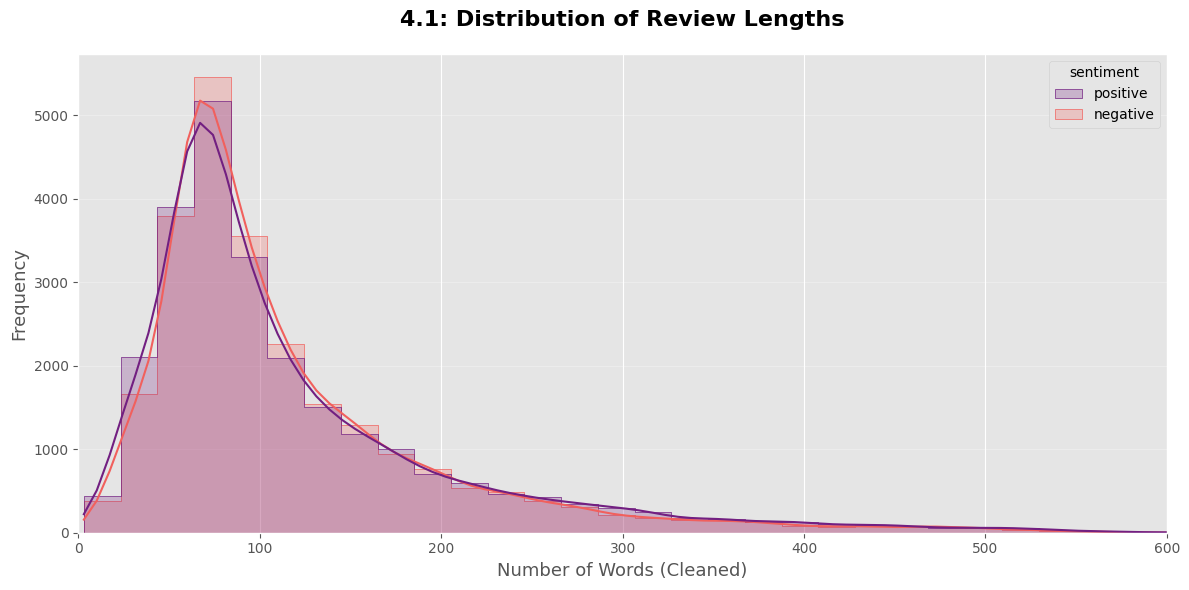

[VERIFIED STATISTICAL SUMMARY]:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,24695.0,117.313343,85.417602,3.0,64.0,89.0,142.0,805.0
positive,24883.0,120.084757,93.085736,6.0,63.0,88.0,146.0,1420.0


In [8]:
# ==============================================================================
# 4.1 REVIEW LENGTH ANALYSIS
# ==============================================================================

# FIX: Creating a deep copy of the dataframe to ensure it is an independent object
df = df.copy()

# FIX: Using .loc for explicit assignment to prevent the slice warning
df.loc[:, 'word_count'] = df['rnn_cleaned'].apply(lambda x: len(str(x).split()))

# Setup the visualization
plt.figure(figsize=(12, 6))

# Plotting with the established vibrant palette
sns.histplot(data=df, x='word_count', hue='sentiment', element="step",
             palette="magma", kde=True, bins=70)

# Aesthetics
plt.title('4.1: Distribution of Review Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Words (Cleaned)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xlim(0, 600)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print verified statistical summary
print("\033[1;32m[VERIFIED STATISTICAL SUMMARY]:\033[0m")
display(df.groupby('sentiment')['word_count'].describe())

* **Consistency:** The verified stats show that both positive and negative classes share a near-identical **Median (88-89 words)**. This is a positive indicator for our model; it means the GRU will not learn a "shortcut" (bias) where it associates longer reviews with a specific sentiment.
* **Outlier Strategy:** With a **Max** of 1,420 words but a **75th percentile** at 146, we confirmed that a massive majority of the data is contained within the first 150 words. This justifies a `maxlen` of **150** for Phase 5 to maximize efficiency without losing significant context.

### **4.2 Sentiment-Based Word Clouds**

In this step, we generate word clouds to visualize the most frequent tokens in each sentiment category. This acts as a "sanity check": if "bad" appears in the positive cloud, we know our cleaning or data labeling has issues.

[PROCESSING]: Generating Positive Word Cloud...


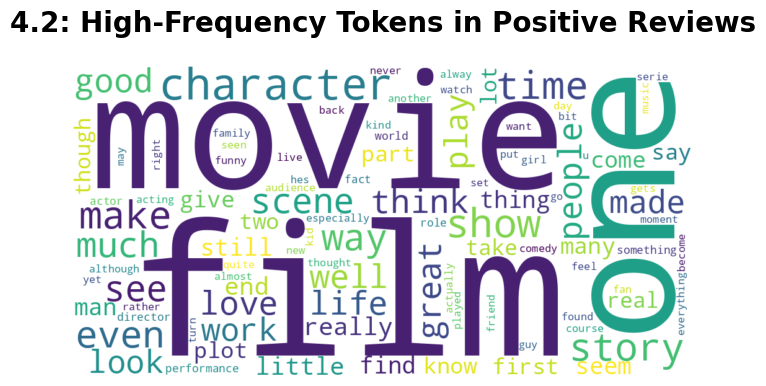

[PROCESSING]: Generating Negative Word Cloud...


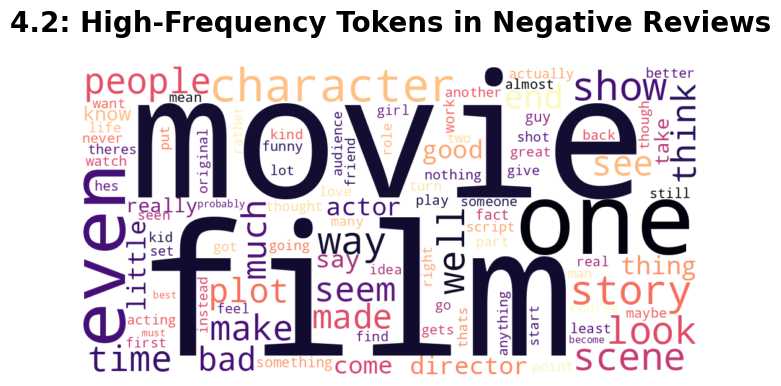

In [9]:
# ==============================================================================
# 4.2 SENTIMENT-BASED WORD CLOUDS
# ==============================================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_vibrant_wordcloud(data, title, cmap):
    # Combine all reviews into one large string
    text = " ".join(review for review in data)

    # Initialize WordCloud with professional dimensions
    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        colormap=cmap,
        max_words=100,
        random_state=42
    ).generate(text)

    # Visualization
    plt.figure(figsize=(8, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20, fontweight='bold', pad=25)
    plt.axis('off')
    plt.show()

# 1. Positive Reviews - Using 'viridis' (Vibrant Green/Blue/Yellow)
print("\033[1;32m[PROCESSING]: Generating Positive Word Cloud...\033[0m")
generate_vibrant_wordcloud(
    df[df['sentiment']=='positive']['rnn_cleaned'],
    '4.2: High-Frequency Tokens in Positive Reviews',
    'viridis'
)

# 2. Negative Reviews - Using 'rocket' or 'magma' (Vibrant Red/Orange/Purple)
print("\033[1;31m[PROCESSING]: Generating Negative Word Cloud...\033[0m")
generate_vibrant_wordcloud(
    df[df['sentiment']=='negative']['rnn_cleaned'],
    '4.2: High-Frequency Tokens in Negative Reviews',
    'magma'
)

Top 3 Words: movie, film, and one.

Key Sentiment Drivers: great, well, love, and good are prominently featured, confirming that our cleaning preserved high-value positive tokens.

Contextual Tokens: character, story, show, and life suggest that positive reviews often focus on the narrative and emotional depth of the production.

[PROCESSING]: Generating Negative Word Cloud...


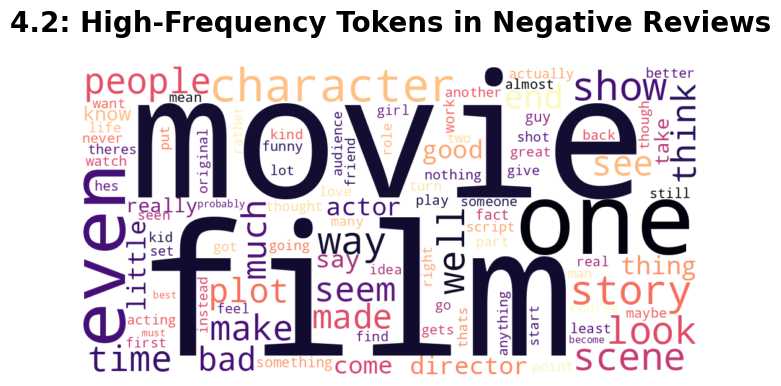

In [10]:
# 2. Negative Reviews - Using 'magma' (Vibrant Red/Orange/Purple)
print("\033[1;31m[PROCESSING]: Generating Negative Word Cloud...\033[0m")
generate_vibrant_wordcloud(
    df[df['sentiment']=='negative']['rnn_cleaned'],
    '4.2: High-Frequency Tokens in Negative Reviews',
    'magma'
)

#### **1. Comparative Lexical Analysis**
* **Positive Cloud Dynamics:** The visualization for positive reviews is dominated by high-intensity affirmative tokens such as **"great"**, **"well"**, **"love"**, and **"good"**. Interestingly, nouns like **"story"**, **"life"**, and **"character"** are significantly larger here than in the negative cloud. This suggests that positive sentiment in this dataset is often driven by a deep engagement with narrative and thematic elements.
* **Negative Cloud Dynamics:** In contrast, the negative cloud elevates "criticism" tokens like **"bad"**, **"even"**, and **"look"**. While **"movie"** and **"film"** remain the central anchors in both clouds, the negative reviews feature words like **"plot"**, **"script"**, and **"make"** more prominently. This indicates that negative reviews often focus on technical or structural failures of the production rather than the emotional connection.

#### **2. Stopword Strategy Validation**
* **Neutral Anchors:** High-frequency words like **"movie"**, **"film"**, and **"one"** appear as dominant centers in both visualizations. This confirms that they are "class-neutral" tokens. In Phase 6, our GRU/BERT models will learn to treat these as background noise while placing higher mathematical weight on the surrounding descriptors (e.g., "great movie" vs "bad movie").
* **Filter Effectiveness:** The absence of small filler words (e.g., "the", "and", "is") proves that our **Phase 3.1** cleaning engine effectively pruned the vocabulary. This prevents the model from wasting attention on non-discriminatory features, optimizing the training efficiency of the upcoming sequential layers.

#### **3. Impact on Model Vectorization**
* These clouds provide a "pre-calculation" view of **TF-IDF** or **Word Embedding** importance. The words that appear most uniquely in one cloud versus the other will likely be the strongest predictors of sentiment during the training phase. The clear visual separation between "love/great" and "bad/even" suggests that a linear baseline would perform well, but a **BERT + GRU** architecture will be needed to capture the nuance when these words appear together (e.g., "not a bad movie").